In [1]:
from pathlib import Path
import warnings
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.base import clone  # Tworzy niezależną kopię estymatora.
from sklearn.dummy import DummyClassifier  # Tworzy prosty model bazowy.
from sklearn.tree import DecisionTreeClassifier  # Importuje klasyfikacyjne drzewo decyzyjne.
from sklearn.ensemble import RandomForestClassifier  # Importuje klasyfikacyjny las losowy.
from sklearn.linear_model import LogisticRegression  # Importuje regresję logistyczną.
from sklearn.pipeline import Pipeline  # Łączy skalowanie i model w jeden obiekt.
from sklearn.preprocessing import StandardScaler  # Standaryzuje cechy dla regresji logistycznej.
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold  # Importuje podział i strojenie modeli.
from sklearn.metrics import (  # Importuje miary jakości klasyfikacji.
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, RocCurveDisplay,
    PrecisionRecallDisplay)

RANDON_STATE = 2022
TARGET = 'default payment next month'
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns',40)

# wczytanie danych

In [2]:
notebook_dir = Path.cwd()  # Przyjmuje bieżący katalog jako katalog notebooka.
xls_candidates = [  # Definiuje możliwe lokalizacje oryginalnego pliku XLS.
    notebook_dir / 'default_of_credit_card_clients.xls',
    Path(r'C:\Users\micha\Desktop\Kodilla_Kurs\Modul20\default_of_credit_card_clients.xls')
]
csv_path = notebook_dir / 'default_of_credit_card_clients.csv'  # Definiuje ścieżkę do kopii CSV.

xls_path = next((path for path in xls_candidates if path.exists()), None)  # Wybiera pierwszą istniejącą ścieżkę XLS.

try:
    if xls_path is None:  # Sprawdza, czy znaleziono oryginalny plik.
        raise FileNotFoundError('Nie znaleziono pliku XLS.')
    dataframe_raw = pd.read_excel(xls_path, header=1)  # Wczytuje XLS z właściwym wierszem nagłówka.
    data_source = str(xls_path)  # Zapamiętuje wykorzystane źródło.
except (ImportError, ModuleNotFoundError, FileNotFoundError):
    dataframe_raw = pd.read_csv(csv_path)  # Wczytuje kopię CSV, jeśli XLS nie może zostać odczytany.
    dataframe_raw = dataframe_raw.iloc[2:].copy()  # Usuwa dwa techniczne wiersze nagłówkowe.
    dataframe_raw.columns = pd.read_csv(csv_path, nrows=2).iloc[1].tolist()  # Ustawia właściwe nazwy kolumn.
    dataframe_raw = dataframe_raw.apply(pd.to_numeric)  # Konwertuje wartości na typy liczbowe.
    data_source = str(csv_path)  # Zapamiętuje wykorzystane źródło.

print('Źródło:', data_source)  # Wyświetla wykorzystany plik.
print('Wymiary danych:', dataframe_raw.shape)  # Wyświetla liczbę wierszy i kolumn.
display(dataframe_raw.head())  # Pokazuje pierwsze obserwacje.

Źródło: C:\Users\micha\Desktop\Kodilla_Kurs\Modul20\default_of_credit_card_clients.csv
Wymiary danych: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
2,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
3,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
4,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
5,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
6,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


# kontrola jakosci danych

In [3]:
dataframe_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 2 to 30001
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [5]:
dataframe_raw.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [9]:
quality_report = pd.DataFrame({
    'dtype' : dataframe_raw.dtypes.astype(str),
    'missing_count' : dataframe_raw.isna().sum(),
    'missing_percent': dataframe_raw.isna().mean().mul(100).round(2),
    'unique_count': dataframe_raw.nunique()
})

display(quality_report)

print ('Duplikaty ID', dataframe_raw['ID'].duplicated().sum())
print ('Pelne duplikaty bez id' , dataframe_raw.drop(columns='ID').duplicated().sum())

,dtype,missing_count,missing_percent,unique_count
ID,int64,0,0.0,30000
LIMIT_BAL,int64,0,0.0,81
SEX,int64,0,0.0,2
EDUCATION,int64,0,0.0,7
MARRIAGE,int64,0,0.0,4
AGE,int64,0,0.0,56
PAY_0,int64,0,0.0,11
PAY_2,int64,0,0.0,11
PAY_3,int64,0,0.0,11
PAY_4,int64,0,0.0,11


Duplikaty ID 0
Pelne duplikaty bez id 35


In [10]:
print('SEX:', sorted(dataframe_raw['SEX'].unique()))  # Sprawdza kody płci.
print('EDUCATION:', sorted(dataframe_raw['EDUCATION'].unique()))  # Sprawdza kody wykształcenia.
print('MARRIAGE:', sorted(dataframe_raw['MARRIAGE'].unique()))  # Sprawdza kody stanu cywilnego.
print('AGE:', dataframe_raw['AGE'].min(), '–', dataframe_raw['AGE'].max())  # Sprawdza zakres wieku.
print('LIMIT_BAL:', dataframe_raw['LIMIT_BAL'].min(), '–', dataframe_raw['LIMIT_BAL'].max())  # Sprawdza zakres limitu.

pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']  # Wskazuje kolumny historii spłat.
for column in pay_columns:  # Przechodzi przez wszystkie miesiące historii spłat.
    print(column, sorted(dataframe_raw[column].unique()))  # Wyświetla zaobserwowane statusy.

SEX: [np.int64(1), np.int64(2)]
EDUCATION: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
AGE: 21 – 79
LIMIT_BAL: 10000 – 1000000
PAY_0 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6 [np.int64

### Wnioski z kontroli jakości

- Brak klasycznych wartości `NaN` i brak powtórzonych identyfikatorów.
- W `EDUCATION` występują nieopisane kody `0`, `5` i `6`; łączymy je z kategorią `4 = inne`.
- W `MARRIAGE` występuje nieopisany kod `0`; łączymy go z kategorią `3 = inne`.
- Statusy spłat zawierają `-2` i `0`, których skrócony opis zadania nie wyjaśnia. Nie usuwamy ich: są częścią oryginalnego kodowania zbioru i niosą informację o braku wykorzystania kredytu lub kredycie odnawialnym.
- Występuje 35 identycznych profili po pominięciu `ID`. Nie usuwamy ich automatycznie, ponieważ mogą reprezentować różnych klientów z tymi samymi wartościami zaokrąglonymi do pełnych dolarów tajwańskich.
- `ID` jest wyłącznie identyfikatorem i zostanie usunięte z modelu.

# akcje po kontroli jakoscie

In [13]:
dataframe = dataframe_raw.copy()
dataframe ['EDUCATION'] = dataframe['EDUCATION'].replace({0:4,5:4,6:4})
dataframe ['MARRIAGE'] = dataframe['MARRIAGE'].replace({0:3})

assert dataframe[TARGET].isin([0, 1]).all()  # Potwierdza binarny charakter zmiennej docelowej.
assert dataframe['ID'].is_unique  # Potwierdza unikalność identyfikatora.
assert dataframe.isna().sum().sum() == 0  # Potwierdza brak pustych wartości.


# 4.Analiza zmiennej docelowej 

,liczba,procent
spłata (0),23364,77.88
brak spłaty (1),6636,22.12


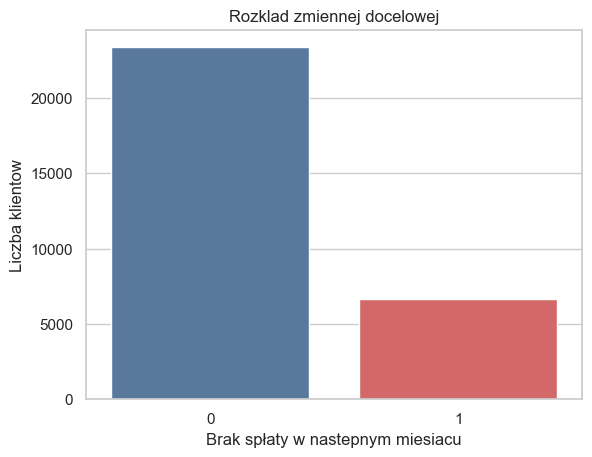

In [17]:
target_counts = dataframe[TARGET].value_counts().sort_index()
target_percent = dataframe[TARGET].value_counts(normalize=True).sort_index().mul(100)
target_summary = pd.DataFrame({'liczba':target_counts, 'procent':target_percent.round(2)})
target_summary.index = ['spłata (0)','brak spłaty (1)']
display(target_summary)

ax=sns.countplot(data=dataframe, x=TARGET, palette=['#4C78A8', '#E45756'])
ax.set(title='Rozklad zmiennej docelowej', xlabel ='Brak spłaty w nastepnym miesiacu', ylabel='Liczba klientow')
plt.show()

4. Dlaczego analizujemy rozkład y?
Kod:
target_counts = dataframe[TARGET].value_counts()
pozwala sprawdzić, ile mamy obserwacji obu klas.
Wynik:
0    23364
1     6636
Dzięki temu wiemy, że:
0 → około 77,88%
1 → około 22,12%
To mówi nam, że klasy są niezbalansowane.

Wpływa to na:
- wybór metryk,
- zastosowanie stratify=y,
- użycie class_weight='balanced',
- wybór progu klasyfikacji,
- interpretację accuracy.
- 
Gdybyśmy nie przeanalizowali celu, moglibyśmy uznać model z accuracy 78% za dobry, mimo że przewidywałby wyłącznie klasę 0.

6. Skąd wiadomo, co oznaczają 0 i 1?
Nie wynika to z samego kodu ani z liczb. Znaczenie pochodzi z dokumentacji zbioru danych:
default payment:
Yes = 1
No = 0
Czyli:
1 = klient nie spłacił zobowiązania
0 = klient spłacił zobowiązanie
Kod:
value_counts()
jedynie liczy wartości. Nie wie, co biznesowo oznaczają.
To my nadajemy im opis na podstawie dokumentacji:
target_summary.index = [
    'spłata (0)',
    'brak spłaty (1)'
]
Można też utworzyć mapowanie:
target_labels = {
    0: 'spłata',
    1: 'brak spłaty'
}

dataframe['target_label'] = dataframe[TARGET].map(
    target_labels
)

# 5. Analiza eksploracyjna

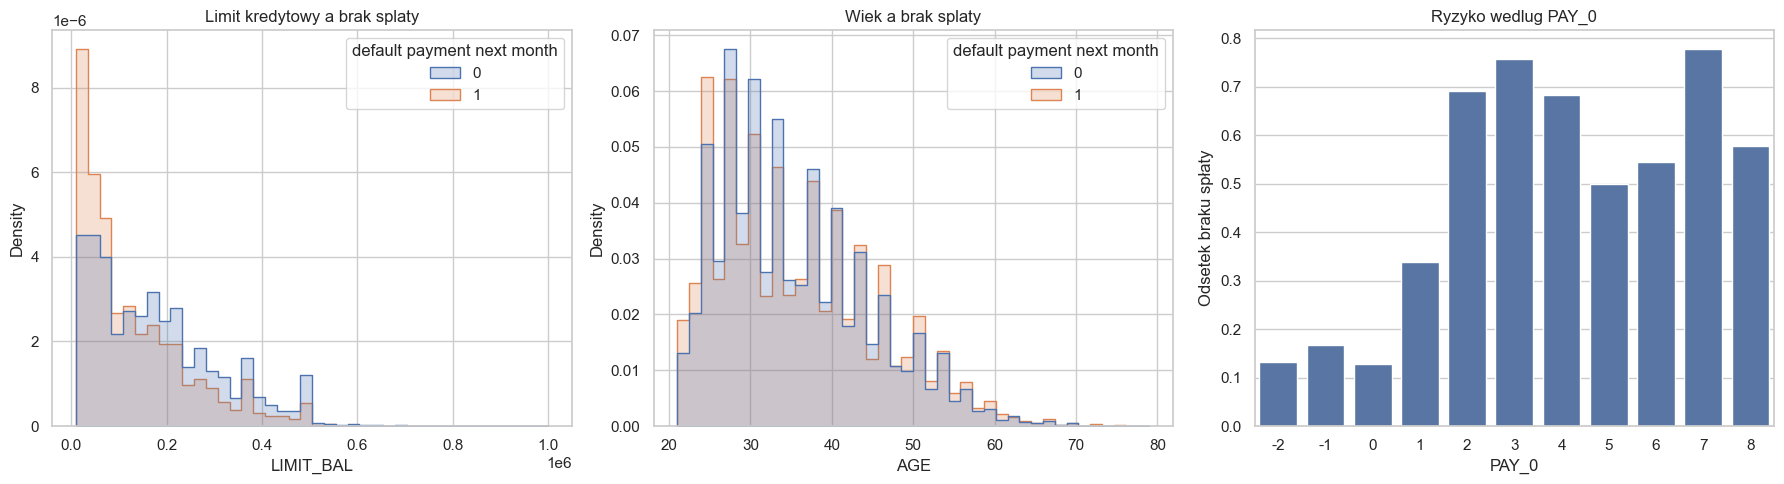

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # Tworzy trzy wykresy obok siebie.
sns.histplot(data=dataframe, x='LIMIT_BAL',  hue=TARGET, bins=40, element='step', stat='density', common_norm=False, ax=axes[0])  # Pokazuje rozkład limitu.
axes[0].set_title('Limit kredytowy a brak splaty')
sns.histplot(data=dataframe,x='AGE', hue=TARGET, bins=40,element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Wiek a brak splaty')
default_by_pay0 = dataframe.groupby('PAY_0')[TARGET].mean().reset_index()  # Oblicza udział braku spłaty według statusu wrześniowego.
sns.barplot(data=default_by_pay0, x='PAY_0',y=TARGET, ax=axes[2])
axes[2].set(title='Ryzyko wedlug PAY_0', ylabel='Odsetek braku spłaty')
plt.tight_layout()
plt.show()

Każdy punkt lub słupek odpowiada jednej wartości PAY_0.
Oś Y (PAY_0) od -2 do 8 pokazuje status spłaty we wrześniu.
Oś X od 0.0 do 0.8 pokazuje odsetek klientów, którzy później nie spłacili zobowiązania.
Wartości na osi X czytamy tak:

0.0 = 0%
0.2 = 20%
0.5 = 50%
0.8 = 80%

Przykład: jeżeli dla PAY_0 = 2 słupek kończy się przy 0.7, oznacza to, że około 70% klientów z dwumiesięcznym opóźnieniem nie spłaciło zobowiązania w następnym miesiącu.
Znaczenie PAY_0:

-2 – brak wykorzystania kredytu / brak transakcji w danym okresie,
-1 – płatność wykonana terminowo,
0 – wykorzystanie kredytu odnawialnego, bez wykazanego opóźnienia,
1 – opóźnienie o miesiąc,
2 – opóźnienie o dwa miesiące,
…
8 – opóźnienie o osiem miesięcy.

Główny wniosek z wykresu: im wyższe PAY_0, czyli większe opóźnienie, tym zazwyczaj większe prawdopodobieństwo braku spłaty.
Jeśli chcesz wyświetlić wartości jako procenty zamiast ułamków:
default_by_pay0['default_percent'] = default_by_pay0[TARGET] * 100
Wtedy oś będzie przedstawiała wartości od 0% do 80%.

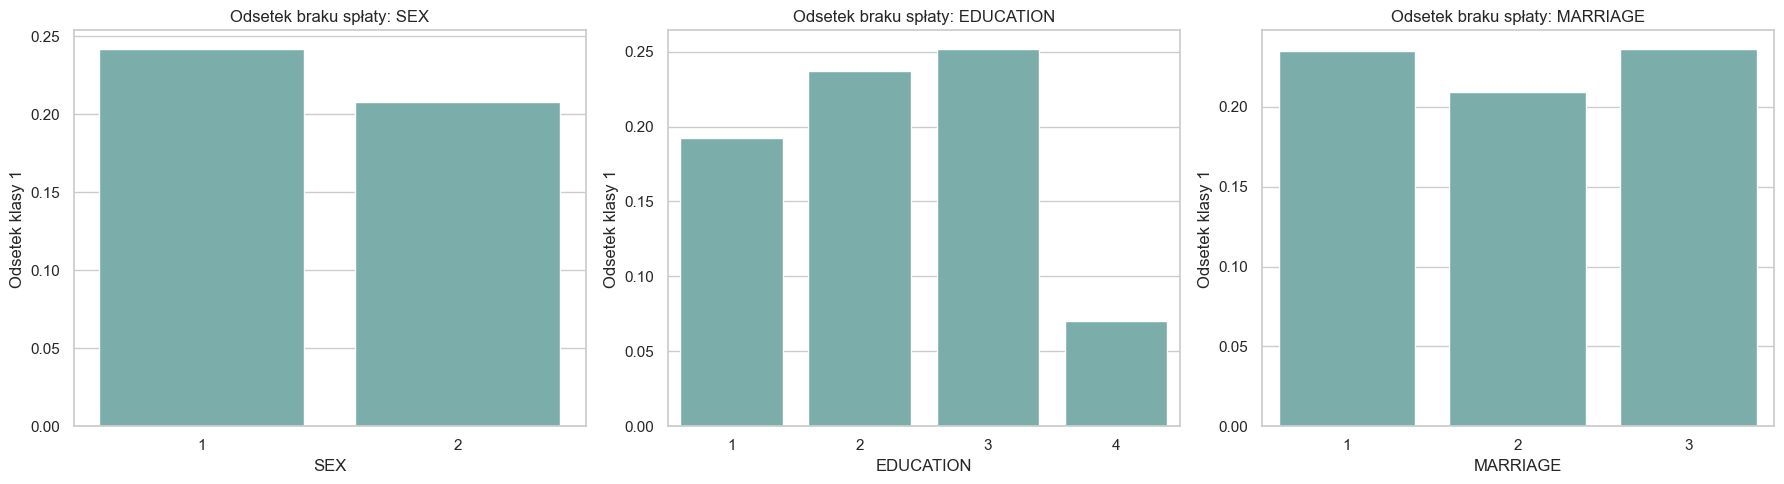

In [31]:
categorical_columns = ['SEX', 'EDUCATION', 'MARRIAGE']  # Wskazuje podstawowe cechy kategoryczne.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # Tworzy miejsce na trzy wykresy.
for column, axis in zip(categorical_columns, axes):  # Łączy kolumnę z osią wykresu.
    rates = dataframe.groupby(column)[TARGET].mean().reset_index()  # Oblicza odsetek braku spłaty w kategorii.
    sns.barplot(data=rates, x=column, y=TARGET, color='#72B7B2', ax=axis)  # Rysuje odsetek braku spłaty.
    axis.set(title=f'Odsetek braku spłaty: {column}', ylabel='Odsetek klasy 1')  # Nadaje opisy.
plt.tight_layout()  # Dopasowuje odstępy.
plt.show()  # Wyświetla wykresy.